Construct a frequency distribution table from a given dataset by grouping the data into class internvals. Represent the data using graphs such as histograms or bar charts.

In [37]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

df_student = pd.read_csv("dataset.csv", delimiter=',', header='infer')

In [116]:
sturges = round(1+np.log2(df_student.Marks.count()))

# freq = pd.cut(df_student["Marks"], bins=sturges, include_lowest=True).value_counts().sort_index()
counts, bins = np.histogram(df_student.Marks, bins=sturges)
# print(counts, bins)
# print(freq_dis.index)
# print(freq.cumsum())
# print(df_student["Marks"].min())

freq_dis = pd.DataFrame({
    'Class Interval': [f'{bins[i-1]} - {bins[i]}' for i in range(1, len(bins))],
    'Frequency': counts,
    'Relative frequency': (counts / len(df_student)).round(2),
    'Cumulative Frequency': counts.cumsum()
})

print(freq_dis)

  Class Interval  Frequency  Relative frequency  Cumulative Frequency
0    35.0 - 45.0          4                0.13                     4
1    45.0 - 55.0          3                0.10                     7
2    55.0 - 65.0          5                0.17                    12
3    65.0 - 75.0          3                0.10                    15
4    75.0 - 85.0          6                0.20                    21
5    85.0 - 95.0          9                0.30                    30


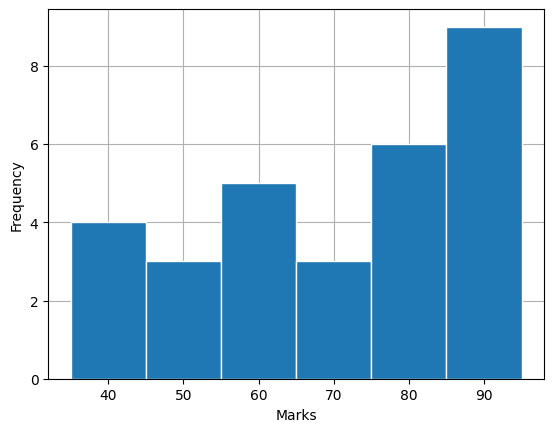

In [83]:
#histogram of marks

plt.hist(df_student.Marks, ec='white', bins=sturges, zorder=2)

plt.xlabel('Marks')
plt.ylabel('Frequency')
# plt.title('Distribution Plot - Histogram')
plt.grid(zorder=0)

plt.show()

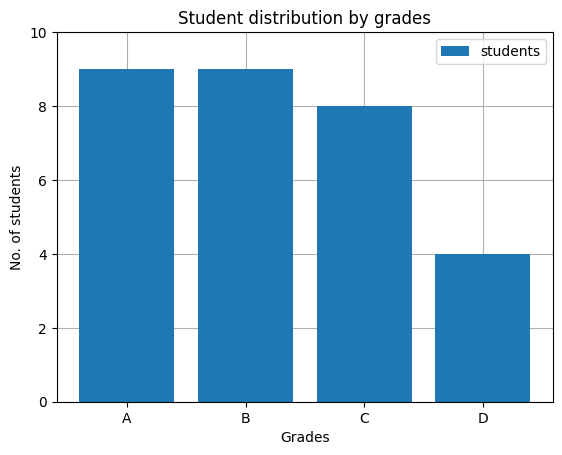

In [62]:
graded = df_student.groupby("Grade").Marks

# print(graded.Marks.count())

plt.bar(graded.count().index, graded.count().values, label = "students", zorder=2)

plt.title("Student distribution by grades")
plt.xlabel("Grades")
plt.ylabel("No. of students")
plt.ylim((0 ,10))
plt.legend()
plt.grid(zorder=0)

plt.show()

In [72]:
list(freq_dis["Cumulative Frequency"].values)

[np.int64(4),
 np.int64(8),
 np.int64(12),
 np.int64(16),
 np.int64(21),
 np.int64(30)]

TypeError: float() argument must be a string or a real number, not 'pandas._libs.interval.Interval'

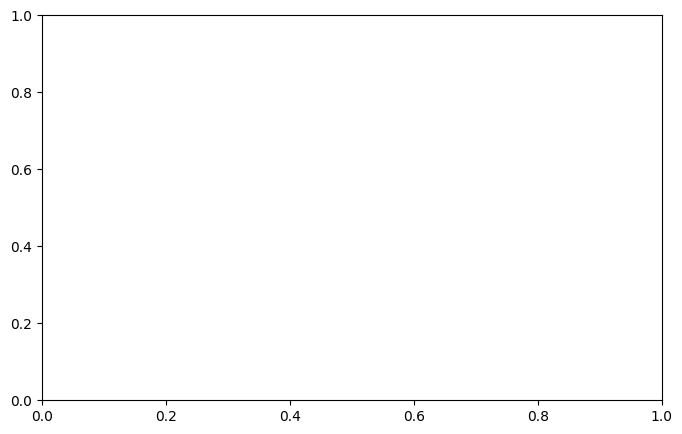

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Example dataset (ungrouped data)
data = [7, 8, 5, 6, 3, 4, 8, 9, 6, 7, 5, 4, 6, 8, 9, 10, 5, 6, 7, 8]

# Step 1: Sort the data
data_sorted = np.sort(data)

# Step 2: Calculate cumulative frequencies
cum_freq = np.arange(1, len(data_sorted) + 1)

# Step 3: Plot the ogive
plt.figure(figsize=(8, 5))
plt.plot(list(freq_dis['Class Interval'].values), list(freq_dis["Cumulative Frequency"].values), marker='o', linestyle='-', color='b', label='Ogive')

# Step 4: Formatting
plt.title("Ogive (Cumulative Frequency Graph)")
plt.xlabel("Data Values")
plt.ylabel("Cumulative Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Step 5: Show the plot
plt.show()


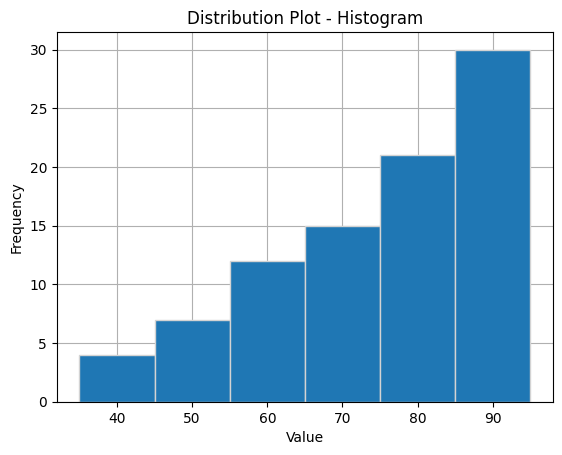

In [80]:
#histogram of marks

plt.hist(df_student.Marks, ec='lightgray', bins=sturges, cumulative=True, zorder=2)

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution Plot - Histogram')
plt.grid(zorder=0)

plt.show()

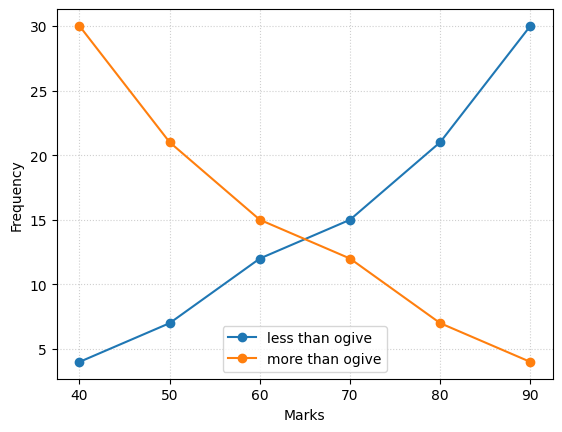

In [117]:
# counts, bins = np.histogram(df_student.Marks, bins=sturges)

bin_centre = []
for i in range(1, len(bins)):
    bin_centre.append((bins[i-1] + bins[i])/2)

plt.plot(bin_centre, counts.cumsum(), "o-", label="less than ogive", zorder=2)
plt.plot(bin_centre, counts.cumsum()[::-1], "o-", label="more than ogive", zorder=3)

plt.xlabel('Marks')
plt.ylabel('Frequency')
# plt.title('Distribution Plot - Histogram')
plt.legend()
plt.grid(zorder=0, linestyle=':', alpha=0.6)

plt.show()

In [108]:
print(df_student.Marks.max())

95
